# BME 1433 — Automated Karyotype Analysis

## Overview

This notebook implements a fully automated pipeline for karyotype image analysis:

1. **Image Exploration** — inspect raw image quality (histogram, CDF, quality metrics)
2. **Quality Filtering** — remove blurry, low-contrast, or unevenly illuminated images before segmentation
3. **Chromosome Segmentation** — three methods compared: active contour, adaptive histogram equalization (CLAHE), and contrast stretching
4. **Feature Extraction** — morphometric features per chromosome (area, length, eccentricity, centromere position, band count)
5. **Denver Group Classification** — assign chromosomes to groups A–G using relative length and centromeric index
6. **Statistical Comparison** — Mann-Whitney U tests, box plots, and ROC analysis comparing normal vs abnormal karyotypes
7. **Overlap Bias Analysis** — quantify how chromosome overlap distorts morphometric measurements

Supporting code is in `algorithms.py` (segmentation) and `helper_functions.py` (feature extraction, classification, plotting).

---
## Dataset

| Folder | Contents |
|--------|----------|
| `chromosomes/` | Full metaphase spread images (used for segmentation exploration) |
| `normal/` | Karyotype images from cytogenetically normal individuals |
| `abnormal/` | Karyotype images from individuals with chromosomal abnormalities |
| `SIngle chromosomes/` | Isolated single-chromosome crops (used for overlap bias analysis) |

---
## 1. Setup

In [ ]:
%load_ext autoreload
%autoreload 2

In [34]:
from helper_functions import *
from algorithms import *
import random
from pathlib import Path
import numpy as np
import pandas as pd
import urllib.request, zipfile, json as _json
random.seed(42)

---
## 2. Data Loading

All paths are relative to the `Downloads` folder. Update `BASE_PATH` below if your data is elsewhere. A random seed ensures the 100-image subset is reproducible across runs.

In [ ]:
ZENODO_ID   = '19490325'
EXTRACT_DIR = Path(*******) #specify the directory to extract the files to


with urllib.request.urlopen(f'https://zenodo.org/api/records/{ZENODO_ID}') as r:
    record = _json.load(r)

for file in record['files']:
    name = file['key']
    url  = file['links']['self']
    dest = EXTRACT_DIR / name

    if not dest.exists():
        print(f'Downloading {name}')
        urllib.request.urlretrieve(url, dest)
    else:
        print(f'{name} already exists, skipping')

    if name.endswith('.zip'):
        folder = EXTRACT_DIR / name.replace('.zip', '')
        if not folder.exists():
            print(f'Extracting {name}...')
            with zipfile.ZipFile(dest) as z:
                z.extractall(EXTRACT_DIR)

print('Done.')

In [ ]:
BASE_DIR     = EXTRACT_DIR  # set in the download cell above

IMG_NORMAL   = BASE_DIR / 'normal'
IMG_ABNORMAL = BASE_DIR / 'abnormal'
OVERLAP_DIR = BASE_DIR / 'overlap'

SUBSET_SIZE = 100

all_normal_chromosomes   = sorted(IMG_NORMAL.glob('*.jpg'))   + sorted(IMG_NORMAL.glob('*.JPG'))
all_abnormal_chromosomes = sorted(IMG_ABNORMAL.glob('*.jpg')) + sorted(IMG_ABNORMAL.glob('*.JPG'))

print(f'Normal images:   {len(all_normal_chromosomes)}')
print(f'Abnormal images: {len(all_abnormal_chromosomes)}')

Normal images:   109
Abnormal images: 51


In [23]:
normal_chromosomes   = random.sample(all_normal_chromosomes,   min(SUBSET_SIZE, len(all_normal_chromosomes)))   if SUBSET_SIZE else all_normal_chromosomes
abnormal_chromosomes = random.sample(all_abnormal_chromosomes, min(SUBSET_SIZE, len(all_abnormal_chromosomes))) if SUBSET_SIZE else all_abnormal_chromosomes
all_imgs      = normal_chromosomes + abnormal_chromosomes

print(f'Sampled normal:   {len(normal_chromosomes)}')
print(f'Sampled abnormal: {len(abnormal_chromosomes)}')
print(f'Total:            {len(all_imgs)}')

Sampled normal:   100
Sampled abnormal: 51
Total:            151


## Image Exploration

Before segmentation we inspect raw image quality to understand the data. Three utilities are used:

- **`display_image_histogram`** — shows the image alongside its foreground intensity histogram (Otsu-masked) and CDF, with mean, median, and p2/p98 annotated
- **`plot_img_and_hist`** — lightweight image + histogram + CDF panel (all pixels, no masking)
- **`compute_image_quality_metrics`** — returns six scalar quality metrics: contrast, sharpness (Laplacian variance), SNR, background uniformity, histogram spread, and local standard-deviation variation

### Intensity histogram & CDF

`display_image_histogram` masks out the white background via Otsu thresholding before computing statistics, so the histogram reflects only chromosome pixels. This makes the mean and dynamic range more meaningful than an all-pixel histogram.

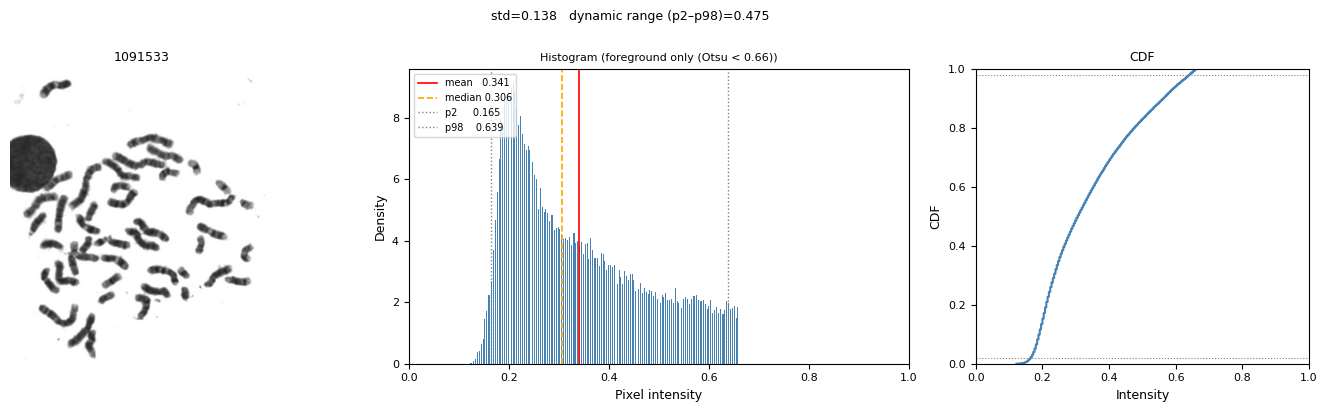

In [24]:
stats = display_image_histogram(all_imgs[0])

### All-pixel histogram

`plot_img_and_hist` shows the full pixel distribution without background masking. The dominant peak near intensity 1.0 reflects the white background, which confirms that background removal is important before computing descriptive statistics.

/opt/anaconda3/lib/python3.13/site-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


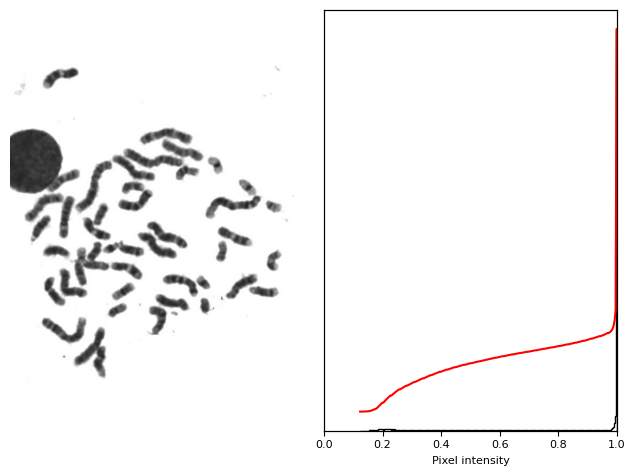

In [15]:
fig, ax_img, ax_hist, ax_cdf = plot_img_and_hist(all_imgs[0])
plt.tight_layout()
plt.show()

### Image quality metrics

`compute_image_quality_metrics` quantifies six properties of each image:

| Metric | Definition |
|--------|------------|
| `contrast` | Global pixel standard deviation |
| `sharpness` | Variance of the Laplacian (higher = sharper) |
| `SNR` | Mean / std of pixel intensities |
| `background_uniformity` | Std of 32×32 block means (lower = more uniform) |
| `histogram_spread` | Std of the 256-bin histogram counts |
| `local_std_variation` | Std of local 15×15 window standard deviations |

Running this across the subset lets us flag outlier images before segmentation.

In [25]:
metrics = compute_image_quality_metrics(all_imgs[0])
for k, v in metrics.items():
    print(f'{k:<28} {v:.4f}')

contrast                     0.2424
sharpness                    0.0008
SNR                          3.6754
background_uniformity        0.1736
histogram_spread             15639.8118
local_std_variation          0.1078


In [26]:
quality_records = []
for p in all_imgs[:20]:          # first 20 images for a quick overview
    m = compute_image_quality_metrics(p)
    m['image'] = p.name
    quality_records.append(m)

df_quality = pd.DataFrame(quality_records).set_index('image')
df_quality.round(4)

,contrast,sharpness,SNR,background_uniformity,histogram_spread,local_std_variation
image,,,,,,
1091533.jpg,0.2424,0.0008,3.6754,0.1736,15639.8118,0.1078
1050282.jpg,0.1179,0.0008,7.2666,0.0821,6227.4524,0.0487
1032292.jpg,0.1430,0.0022,6.1193,0.0976,6879.5329,0.0657
1100802.jpg,0.2314,0.0007,3.8595,0.1654,17111.3925,0.0977
1053591.jpg,0.2555,0.0007,3.2459,0.2268,13257.8921,0.0701
1052661.jpg,0.2178,0.0007,4.0189,0.1656,14190.3674,0.0844
1052262.jpg,0.2127,0.0006,4.0166,0.1766,14813.0531,0.0677
1050364.jpg,0.1375,0.0006,6.7792,0.0926,11641.7684,0.0617
1101222.jpg,0.1370,0.0026,7.0364,0.0771,44492.0399,0.0839


## Image Quality Filtering

Before running segmentation, images that are too blurry, too low-contrast, or unevenly illuminated are removed. These images tend to produce unreliable segmentation masks and inflate measurement noise downstream.

Quality metrics are computed for every image in the subset. Images are rejected if they fall below the **10th percentile** on any of three criteria:

| Metric | Filter | Reason |
|--------|--------|---------|
| `sharpness` | < p10 | Blurry images cause chromosome edges to blur into background |
| `contrast` | < p10 | Low-contrast images make it hard to separate chromosomes from background |
| `background_uniformity` | > p90 | Uneven illumination shifts the local intensity baseline, causing patchy thresholding |

Percentile-based thresholds adapt to the actual distribution of the loaded subset rather than relying on fixed absolute values.

In [27]:
def compute_quality(imgs, label):
    print(f'Computing quality metrics for {label} images...')
    records = []
    for p in imgs:
        m = compute_image_quality_metrics(p)
        m['path']  = p
        m['image'] = p.name
        records.append(m)
    df = pd.DataFrame(records)
    print(f'  {len(df)} images evaluated')
    return df

df_quality_normal   = compute_quality(normal_chromosomes,   'Normal')
df_quality_abnormal = compute_quality(abnormal_chromosomes, 'Abnormal')


Computing quality metrics for Normal images...
  100 images evaluated
Computing quality metrics for Abnormal images...
  51 images evaluated


In [28]:
def apply_quality_filter(df, label):
    sharp_thresh    = df['sharpness'].quantile(0.10)
    contrast_thresh = df['contrast'].quantile(0.10)
    uniform_thresh  = df['background_uniformity'].quantile(0.90)

    mask_bad = (
        (df['sharpness']             < sharp_thresh)   |
        (df['contrast']              < contrast_thresh) |
        (df['background_uniformity'] > uniform_thresh)
    )

    df_bad  = df[mask_bad]
    df_good = df[~mask_bad]

    print(f'--- {label} ---')
    print(f'Removed : {mask_bad.sum()} images')
    print(f'Kept    : {(~mask_bad).sum()} images')
    print(f'Thresholds used:')
    print(f'  sharpness             >= {sharp_thresh:.4f}')
    print(f'  contrast              >= {contrast_thresh:.4f}')
    print(f'  background_uniformity <= {uniform_thresh:.4f}')
    if len(df_bad) > 0:
        print(f'Rejected images:')
        print(df_bad[['image', 'sharpness', 'contrast', 'background_uniformity']].round(4).to_string())
    print()
    return df_good

df_good_normal   = apply_quality_filter(df_quality_normal,   'Normal')
df_good_abnormal = apply_quality_filter(df_quality_abnormal, 'Abnormal')


--- Normal ---
Removed : 28 images
Kept    : 72 images
Thresholds used:
  sharpness             >= 0.0003
  contrast              >= 0.1215
  background_uniformity <= 0.1654
Rejected images:
          image  sharpness  contrast  background_uniformity
0   1091533.jpg     0.0008    0.2424                 0.1736
1   1050282.jpg     0.0008    0.1179                 0.0821
4   1053591.jpg     0.0007    0.2555                 0.2268
5   1052661.jpg     0.0007    0.2178                 0.1656
6   1052262.jpg     0.0006    0.2127                 0.1766
10  1100103.jpg     0.0003    0.1843                 0.1451
11  1100928.jpg     0.0005    0.1163                 0.0769
14  1080752.jpg     0.0003    0.1154                 0.0798
18  1100841.jpg     0.0002    0.1155                 0.0904
20  1052402.jpg     0.0006    0.2043                 0.1694
21  1060841.jpg     0.0024    0.1193                 0.0734
24  1080141.jpg     0.0002    0.1446                 0.1001
34  1100753.jpg     0.0002   

In [29]:
normal_chromosomes   = list(df_good_normal['path'])
abnormal_chromosomes = list(df_good_abnormal['path'])
all_imgs      = normal_chromosomes + abnormal_chromosomes

print(f'normal_chromosomes   updated: {len(normal_chromosomes)} images')
print(f'abnormal_chromosomes updated: {len(abnormal_chromosomes)} images')
print(f'all_imgs      updated: {len(all_imgs)} images ready for segmentation')


normal_chromosomes   updated: 72 images
abnormal_chromosomes updated: 39 images
all_imgs      updated: 111 images ready for segmentation


---
## 3. Chromosome Segmentation

Three segmentation approaches are compared:

| Method | Enhancement | Separation |
|--------|-------------|------------|
| Active Contour | CLAHE + top-hat | Snake refinement per blob |
| Adaptive Histogram (CLAHE) | CLAHE + top-hat | Otsu + watershed |
| Contrast Stretching | Percentile rescaling + top-hat | Local Gaussian threshold |

All methods apply Gaussian pre-smoothing (σ = 0.3), remove border-touching objects, and filter detections by area, eccentricity, and solidity.

In [36]:
sample_img_index = 20

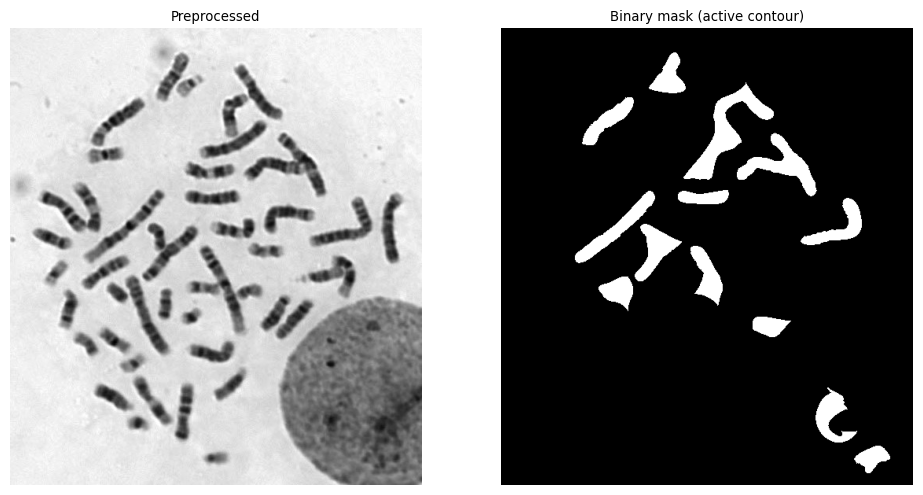

In [37]:
mask_active_contour = chromosome_mask_with_active_contour(all_imgs[sample_img_index], plot=True)

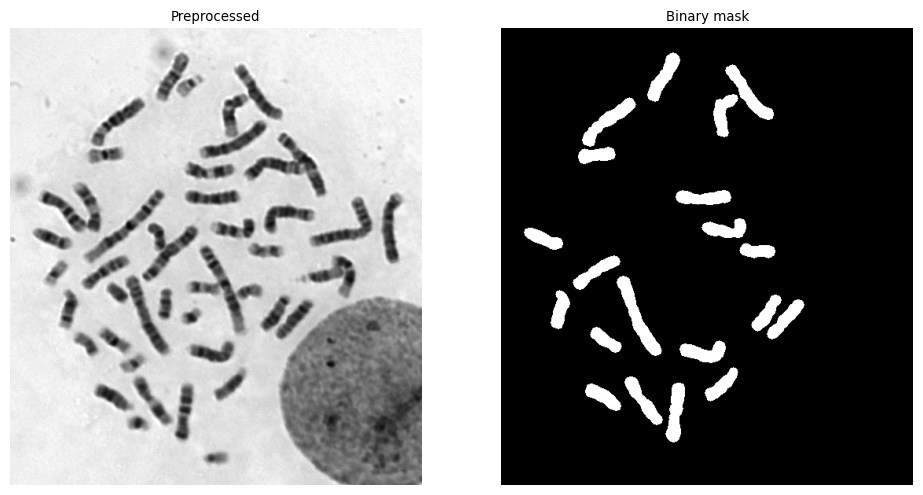

In [41]:
mask_contrast_stretching = chromosome_mask_with_contrast_stretching(all_imgs[sample_img_index], plot=True)

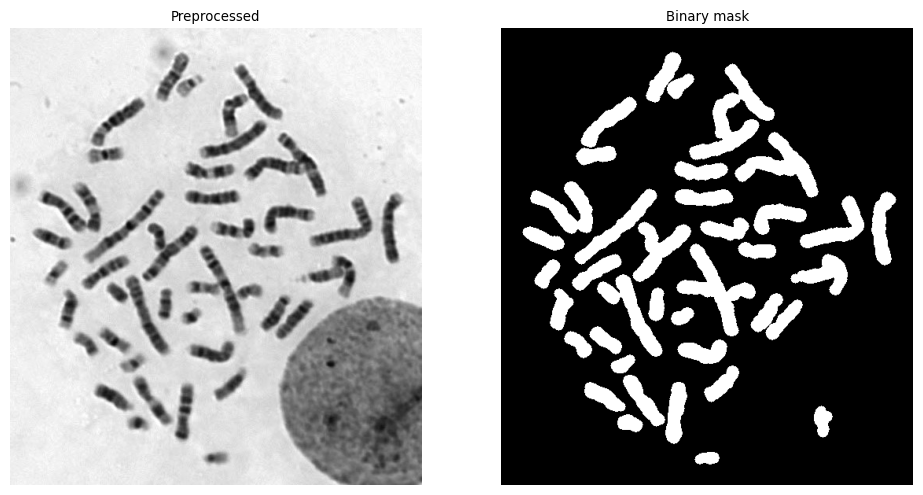

In [40]:
mask_adaptive_histogram = chromosome_mask_with_adaptive_histogram(all_imgs[sample_img_index],plot=True,)

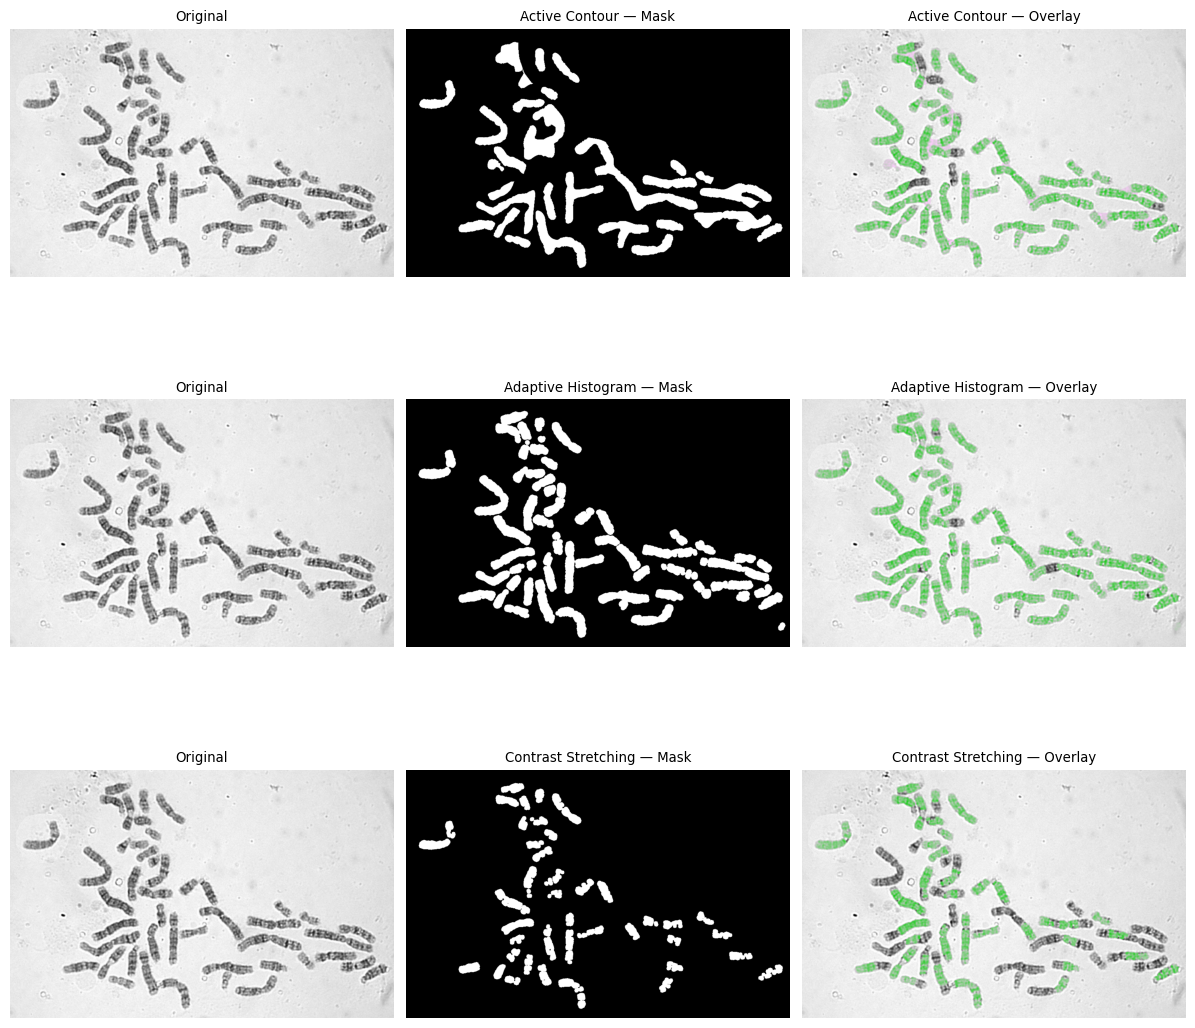

In [42]:
index    = 20
img_gray = skimage.io.imread(all_imgs[index], as_gray=True)
img_rgb  = np.stack([img_gray] * 3, axis=-1)

algorithms = {
    'Active Contour':      chromosome_mask_with_active_contour,
    'Adaptive Histogram':  chromosome_mask_with_adaptive_histogram,
    'Contrast Stretching': chromosome_mask_with_contrast_stretching,
}

fig, axes = plt.subplots(len(algorithms), 3, figsize=(12, 4 * len(algorithms)))

for row, (name, fn) in enumerate(algorithms.items()):
    mask    = fn(all_imgs[index], plot=False)
    overlay = img_rgb.copy()
    overlay[mask, 1] = 0.8

    axes[row, 0].imshow(img_gray, cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f'{name} — Mask')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'{name} — Overlay')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.imsave('segmentation_comparison.png', fig.canvas.buffer_rgba())
plt.show()


## Semi-Automated Watershed with Manual Seed Editing

When chromosomes are heavily clustered or touching, the fully automated watershed may under-segment (merge two chromosomes into one region) or over-segment (split a single chromosome). The semi-automated workflow lets you inspect and correct the watershed seeds before the final segmentation is computed:

**Step 1 — Auto-seed + napari viewer**  
Run `napari_semi_auto_seed_watershed` to:
1. Apply the standard CLAHE → top-hat → Otsu pipeline to get a binary mask
2. Compute the distance transform and detect local maxima as initial seeds
3. Open a napari window showing the image, binary mask overlay, and a red-dot `Points` layer for each auto-detected seed

**Step 2 — Edit seeds in napari**  
In the napari viewer:
- Press **P** (or click the Points tool) and click to **add** a seed over any missed chromosome
- Select a point and press **Delete** to **remove** a spurious seed
- Drag points to **reposition** them

**Step 3 — Run watershed**  
Pass the edited `points_layer` to `run_manual_seed_watershed` to produce the final label image.

> **Note:** napari requires a display — uncomment the cells below to run interactively.

In [ ]:
# # Step 1 — open napari with auto-detected seeds
# viewer, points_layer, binary_mask = napari_semi_auto_seed_watershed(
#     all_imgs[8],
#     gaussian_sigma=0.3,
#     clahe_clip_limit=0.03,
#     tophat_disk_size=15,
#     opening_disk_size=5,
#     min_object_size=600,
#     min_distance=10,
# )
# napari.run()   # blocks until the viewer window is closed


Edit the seeds in the napari viewer (add / delete / move red dots), then close the viewer and run the cell below.

In [ ]:
# # Step 2 — run watershed with the corrected seeds
# labels_ws = run_manual_seed_watershed(points_layer, binary_mask)

# img_gray = skimage.io.imread(all_imgs[8], as_gray=True)
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# axes[0].imshow(img_gray,    cmap='gray');         axes[0].set_title('Original')
# axes[1].imshow(binary_mask, cmap='gray');         axes[1].set_title('Binary mask')
# axes[2].imshow(labels_ws,   cmap='nipy_spectral'); axes[2].set_title(f'Manual watershed ({labels_ws.max()} chromosomes)')
# for ax in axes: ax.axis('off')
# plt.tight_layout(); plt.show()
# print(f'Chromosomes detected after manual correction: {labels_ws.max()}')


In [ ]:
MASK_DIR       = Path('gt_masks')
CHROMOSOME_DIR = Path('normal')

def dice(auto, gt):
    auto, gt = auto.astype(bool), gt.astype(bool)
    return 2 * np.logical_and(auto, gt).sum() / (auto.sum() + gt.sum())

def iou(auto, gt):
    auto, gt = auto.astype(bool), gt.astype(bool)
    return np.logical_and(auto, gt).sum() / np.logical_or(auto, gt).sum()

rows = []
for mask_file in sorted(MASK_DIR.glob('*_mask.png')):
    img_file = CHROMOSOME_DIR / mask_file.name.replace('_mask.png', '.jpg')
    if not img_file.exists():
        print(f'no image for {mask_file.name}, skipping')
        continue

    pred = chromosome_mask_with_adaptive_histogram(img_file, plot=False)
    gt   = skimage.io.imread(str(mask_file), as_gray=True) > 0.5

    rows.append({
        'image': img_file.name,
        'dice' : round(dice(pred, gt), 4),
        'iou'  : round(iou(pred, gt),  4),
    })

val_df = pd.DataFrame(rows)
print(val_df.to_string(index=False))
print(f"\nMean DICE: {val_df['dice'].mean():.4f}  |  Mean IoU: {val_df['iou'].mean():.4f}")

val_df.to_csv(MASK_DIR / 'dice_validation_results.csv', index=False)

---
## 4. Feature Extraction

`extract_chromosome_features` segments each image with CLAHE + watershed and returns one row per chromosome: area, major/minor axis length, eccentricity, solidity, centroid, orientation, and bounding box.

`extract_centromere_and_bands` then aligns each crop (long axis vertical), locates the centromere as the row of minimum width in the middle 50% of the chromosome, and counts dark bands via Savitzky-Golay peak detection.

Low-solidity detections (`solidity ≤ 0.8`) and images with fewer than 20 detected chromosomes are filtered out before classification.

In [ ]:
from helper_functions import classify_denver_groups, extract_centromere_and_bands, extract_chromosome_features

df_abnormal       = extract_chromosome_features(all_abnormal_chromosomes, method='adaptive_histogram', plot=False)
df_abnormal       = df_abnormal[df_abnormal['solidity'] > 0.6]
df_abnormal       = df_abnormal[df_abnormal['eccentricity'] > 0.7]

# filter out images with too few detected chromosomes (avoids inflated relative lengths)
min_chrom         = 20
counts            = df_abnormal.groupby('image_name')['chromosome_label'].count()
valid             = counts[counts >= min_chrom].index
df_abnormal       = df_abnormal[df_abnormal['image_name'].isin(valid)]
print(f'Abnormal — images kept: {len(valid)} / {counts.shape[0]}  |  chromosomes: {len(df_abnormal)}')

df_abnormal            = extract_centromere_and_bands(df_abnormal, plot=True)
df_classified_abnormal = classify_denver_groups(df_abnormal)


In [ ]:
df_normal         = extract_chromosome_features(all_normal_chromosomes, method='adaptive_histogram', plot=False)
df_normal         = df_normal[df_normal['solidity'] > 0.6]
df_normal = df_normal[df_normal['eccentricity'] > 0.7] 

# filter out images with too few detected chromosomes (avoids inflated relative lengths)
min_chrom         = 20
counts            = df_normal.groupby('image_name')['chromosome_label'].count()
valid             = counts[counts >= min_chrom].index
df_normal         = df_normal[df_normal['image_name'].isin(valid)]
print(f'Normal — images kept: {len(valid)} / {counts.shape[0]}  |  chromosomes: {len(df_normal)}')

df_normal         = extract_centromere_and_bands(df_normal, plot=True)
df_classified_normal = classify_denver_groups(df_normal)


## Denver Group Morphometric Summary — Normal vs Abnormal
Ranges of relative length (%), arm ratio, and centromeric index per Denver group

In [ ]:
GROUPS = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

def denver_summary_table(df, label):
    rows = []
    for g in GROUPS:
        sub = df[df['denver_group'] == g].dropna(subset=['relative_length', 'arm_ratio', 'centromeric_index'])
        if len(sub) == 0:
            rows.append({'Group': g, f'Rel. Length {label}': '—', f'Arm Ratio {label}': '—', f'CI {label}': '—'})
            continue
        rows.append({
            'Group':              g,
            f'Rel. Length {label}': f"{sub['relative_length'].min():.1f}–{sub['relative_length'].max():.1f}",
            f'Arm Ratio {label}':   f"{sub['arm_ratio'].min():.1f}–{sub['arm_ratio'].max():.1f}",
            f'CI {label}':          f"{(sub['centromeric_index']*100).min():.0f}–{(sub['centromeric_index']*100).max():.0f}",
        })
    return pd.DataFrame(rows).set_index('Group')

table = pd.concat([
    denver_summary_table(df_classified_normal,   'Normal'),
    denver_summary_table(df_classified_abnormal, 'Abnormal'),
], axis=1)

display(table)
table.to_csv('denver_table2.csv')
table.to_latex('denver_table2.tex')

## Statistical Comparison — Normal vs Abnormal
### 1. Mann-Whitney U Test (per group, per feature)

In [ ]:
from scipy.stats import mannwhitneyu

GROUPS   = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
FEATURES = {
    'Rel. Length':        'relative_length',
    'Arm Ratio':          'arm_ratio',
    'CI (length-based)':  'centromeric_index',
}

stat_rows = []
for group in GROUPS:
    for feat_name, col in FEATURES.items():
        n = df_classified_normal[df_classified_normal['denver_group'] == group][col].dropna()
        a = df_classified_abnormal[df_classified_abnormal['denver_group'] == group][col].dropna()

        if len(n) < 3 or len(a) < 3:
            stat_rows.append({'Group': group, 'Feature': feat_name,
                              'p-value': np.nan, 'Significant': '—', 'n_normal': len(n), 'n_abnormal': len(a)})
            continue

        stat, p = mannwhitneyu(n, a, alternative='two-sided')

        # Cohen's d effect size
        pooled_std = np.sqrt((n.std()**2 + a.std()**2) / 2)
        d = (n.mean() - a.mean()) / pooled_std if pooled_std > 0 else np.nan

        stat_rows.append({
            'Group':      group,
            'Feature':    feat_name,
            'n_normal':   len(n),
            'n_abnormal': len(a),
            'p-value':    round(p, 4),
            "Cohen's d":  round(d, 3) if not np.isnan(d) else np.nan,
            'Significant': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')),
        })

df_stats = pd.DataFrame(stat_rows)

styled_stats = (df_stats.style
    .set_caption("Mann-Whitney U test — Normal vs Abnormal per Denver group. "
                 "* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")
    .applymap(lambda v: 'background-color: #d4edda' if v in ('*','**','***') else
                        ('background-color: #f8d7da' if v == 'ns' else ''),
              subset=['Significant'])
    .format({'p-value': '{:.4f}', "Cohen's d": '{:.3f}'}, na_rep='—')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                     ('border', '1px solid #ccc'), ('padding', '4px 8px')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '4px 8px'),
                                     ('text-align', 'center')]},
    ])
)
display(styled_stats)


### 2. Feature Distributions — Box Plots per Denver Group

In [ ]:
df_classified_normal['condition']   = 'Normal'
df_classified_abnormal['condition'] = 'Abnormal'
df_combined = pd.concat([df_classified_normal, df_classified_abnormal], ignore_index=True)
df_combined = df_combined[df_combined['denver_group'].isin(GROUPS)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (feat_name, col) in zip(axes, FEATURES.items()):
    data_normal   = [df_combined[(df_combined['denver_group'] == g) &
                                  (df_combined['condition'] == 'Normal')][col].dropna()
                     for g in GROUPS]
    data_abnormal = [df_combined[(df_combined['denver_group'] == g) &
                                  (df_combined['condition'] == 'Abnormal')][col].dropna()
                     for g in GROUPS]

    x     = np.arange(len(GROUPS))
    width = 0.35

    bp1 = ax.boxplot(data_normal,   positions=x - width/2, widths=width*0.9,
                     patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='navy', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))
    bp2 = ax.boxplot(data_abnormal, positions=x + width/2, widths=width*0.9,
                     patch_artist=True,
                     boxprops=dict(facecolor='tomato', alpha=0.6),
                     medianprops=dict(color='darkred', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))

    ax.set_xticks(x)
    ax.set_xticklabels(GROUPS)
    ax.set_xlabel('Denver Group')
    ax.set_title(feat_name)
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Normal', 'Abnormal'], fontsize=9)

plt.suptitle('Feature distributions per Denver Group — Normal vs Abnormal', fontsize=13)
plt.tight_layout()
plt.show()


### 3. ROC Curve — Can morphometric features distinguish Normal vs Abnormal?

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline

feature_cols = ['relative_length', 'arm_ratio', 'centromeric_index']

df_ml = df_combined[feature_cols + ['condition']].dropna()
X     = df_ml[feature_cols].values
y     = (df_ml['condition'] == 'Abnormal').astype(int).values

pipe  = Pipeline([('scaler', StandardScaler()),
                  ('clf',    LogisticRegression(max_iter=1000))])
pipe.fit(X, y)
y_prob = pipe.predict_proba(X)[:, 1]

fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc     = auc(fpr, tpr)

# individual feature ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='navy', lw=2,
        label=f'All features (AUC = {roc_auc:.2f})')

for feat_name, col in FEATURES.items():
    d  = df_combined[[col, 'condition']].dropna()
    xf = d[col].values
    yf = (d['condition'] == 'Abnormal').astype(int).values
    fpr_f, tpr_f, _ = roc_curve(yf, xf)
    ax.plot(fpr_f, tpr_f, lw=1.2, linestyle='--',
            label=f'{feat_name} (AUC = {auc(fpr_f, tpr_f):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Normal vs Abnormal classification')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nLogistic Regression AUC (all features): {roc_auc:.3f}")
print("AUC > 0.7 suggests the features carry discriminatory power.")


---
## Overlap Bias Analysis

Chromosome overlap distorts morphometric measurements — a merged cluster will appear larger, less elongated, and with a shifted centromere position compared to an isolated chromosome. This section quantifies how much each feature is biased by overlap by comparing two groups:

- **Low overlap** — single isolated chromosome images (`SIngle chromosomes/`)
- **High overlap** — full metaphase spread images (`chromosomes/`) where chromosomes frequently touch

Features are extracted using `extract_chromosome_features` and `extract_centromere_and_bands` — the same functions used throughout the rest of the pipeline. For each feature, a Shapiro-Wilk normality test selects between a t-test (normal) or Mann-Whitney U (non-normal), and Cohen's d ranks the features by effect size.

In [ ]:
from scipy import stats

SINGLE_DIR  = IMG_NORMAL          # defined in the data loading cell above
OVERLAP_DIR = Path('Overlap')     # place your Overlap folder next to the notebook

print(f'Looking for images in:\n  {SINGLE_DIR}\n  {OVERLAP_DIR}\n')
single_imgs  = sorted(SINGLE_DIR.glob('*.jpg'))  + sorted(SINGLE_DIR.glob('*.JPG'))
overlap_imgs = sorted(OVERLAP_DIR.glob('*.jpg')) + sorted(OVERLAP_DIR.glob('*.JPG'))

print(f'Single chromosome images : {len(single_imgs)}')
print(f'Overlap (spread) images  : {len(overlap_imgs)}')

In [ ]:
print('Extracting features from single chromosomes...')
df_single  = extract_chromosome_features(single_imgs,  method='adaptive_histogram', plot=False)
df_single  = extract_centromere_and_bands(df_single,  plot=False)
df_single  = classify_denver_groups(df_single)
print(df_single.columns)
df_single['centromere_index'] = (df_single['centromere_position'] / df_single['aligned_length']) * 100
df_single['group'] = 'low_overlap'
print(f'  {len(df_single)} detections')

print('Extracting features from overlap spreads...')
df_overlap = extract_chromosome_features(overlap_imgs, method='adaptive_histogram', plot=False)
df_overlap = extract_centromere_and_bands(df_overlap, plot=False)
df_overlap = classify_denver_groups(df_overlap)
df_overlap['centromere_index'] = (df_overlap['centromere_position'] / df_overlap['aligned_length']) * 100
df_overlap['group'] = 'high_overlap'
print(f'  {len(df_overlap)} detections')

df_overlap_combined = pd.concat([df_single, df_overlap], ignore_index=True)
print(f'\nTotal: {len(df_overlap_combined)} chromosomes')

In [ ]:
FEATURES = {
    'arm_ratio':         'arm_ratio',
    'relative_length':   'relative_length',
    'centromere_index':  'centromere_index',
    'eccentricity':      'eccentricity',
    'solidity':          'solidity',
}

low  = df_overlap_combined[df_overlap_combined['group'] == 'low_overlap']
high = df_overlap_combined[df_overlap_combined['group'] == 'high_overlap']

bias_rows = []
for feat_name, col in FEATURES.items():
    low_vals  = low[col].dropna()
    high_vals = high[col].dropna()

    if len(low_vals) < 3 or len(high_vals) < 3:
        continue

    _, p_normal = stats.shapiro(low_vals[:5000])  # Shapiro-Wilk limited to 5000
    if p_normal > 0.05:
        _, p      = stats.ttest_ind(low_vals, high_vals)
        test_used = 't-test'
    else:
        _, p      = stats.mannwhitneyu(low_vals, high_vals, alternative='two-sided')
        test_used = 'Mann-Whitney U'

    pooled_std = np.sqrt((low_vals.std()**2 + high_vals.std()**2) / 2)
    cohens_d   = abs(low_vals.mean() - high_vals.mean()) / pooled_std if pooled_std > 0 else 0
    bias_pct   = ((high_vals.mean() - low_vals.mean()) / low_vals.mean()) * 100

    bias_rows.append({
        'Feature':          feat_name,
        'Low mean ± SD':    f'{low_vals.mean():.2f} ± {low_vals.std():.2f}',
        'High mean ± SD':   f'{high_vals.mean():.2f} ± {high_vals.std():.2f}',
        'Bias %':           round(bias_pct, 2),
        'Test':             test_used,
        'p-value':          round(p, 4),
        'Significant':      'Yes' if p < 0.05 else 'No',
        "Cohen's d":        round(cohens_d, 3),
        'Effect Size':      'Large' if cohens_d >= 0.8 else ('Medium' if cohens_d >= 0.5 else 'Small'),
    })

bias_df = pd.DataFrame(bias_rows).sort_values("Cohen's d", ascending=False)

styled_bias = (bias_df.style
    .set_caption('Overlap bias analysis — effect of chromosome overlap on morphometric features. '
                 'Sorted by Cohen\'s d (largest effect first).')
    .map(lambda v: 'background-color: #d4edda' if v == 'Yes' else
                   ('background-color: #f8d7da' if v == 'No' else ''),
         subset=['Significant'])
    .format({'p-value': '{:.4f}'}, na_rep='—')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                     ('border', '1px solid #ccc'), ('padding', '4px 8px')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '4px 8px'),
                                     ('text-align', 'center')]},
    ])
)
display(styled_bias)

top = bias_df.iloc[0]
print(f"Most affected feature: '{top['Feature']}' Cohen's d = {top["Cohen's d"]}, Bias = {top['Bias %']}%")